In [1]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Bidirectional,Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [3]:
df=pd.read_csv("IMDB Dataset.csv")
df.isnull().sum()
df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
label=LabelEncoder()
df["sentiment"]=label.fit_transform(df["sentiment"])

In [5]:
X=df["review"].values
y=df["sentiment"].values


In [6]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
vocab_size=10000
max_length=200

tokenizer=Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(x_train)

In [8]:
x_train_seq=tokenizer.texts_to_sequences(x_train)
x_test_seq=tokenizer.texts_to_sequences(x_test)

In [9]:
x_train_pad=pad_sequences(x_train_seq,maxlen=max_length)
x_test_pad=pad_sequences(x_test_seq,maxlen=max_length)

In [10]:
model=Sequential([
    Embedding(input_dim=vocab_size,output_dim=128,input_length=max_length),
    Bidirectional(LSTM(64)),
    Dense(1,activation="sigmoid")
])

c:\Users\AKASH\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [11]:
model.compile(loss="binary_crossentropy",optimizer="adam",metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
history=model.fit(
    x_train_pad,y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=128,
    verbose=1
)

Epoch 1/5


250/250 ━━━━━━━━━━━━━━━━━━━━ 100s 400ms/step - accuracy: 0.9087 - loss: 0.2315 - val_accuracy: 0.9046 - val_loss: 0.2357
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 105s 421ms/step - accuracy: 0.9352 - loss: 0.1720 - val_accuracy: 0.8994 - val_loss: 0.2707
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 104s 416ms/step - accuracy: 0.9497 - loss: 0.1354 - val_accuracy: 0.8961 - val_loss: 0.2688
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 102s 407ms/step - accuracy: 0.9618 - loss: 0.1060 - val_accuracy: 0.8967 - val_loss: 0.3022
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 106s 426ms/step - accuracy: 0.9721 - loss: 0.0801 - val_accuracy: 0.8891 - val_loss: 0.3453


In [14]:
loss,accuracy=model.evaluate(x_test_pad,y_test)
print(f"Loss: {loss}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8793 - loss: 0.3766
Loss: 0.3766148090362549


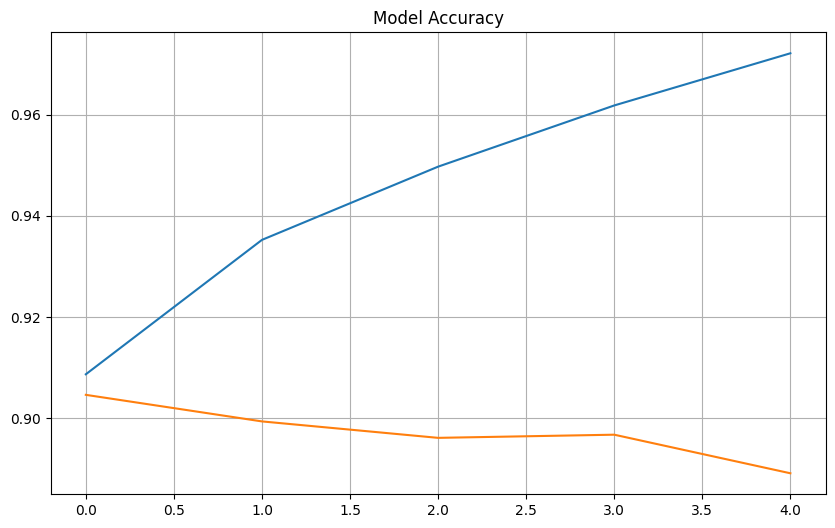

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.grid()
plt.show()


In [18]:
def encode_review(review):
    seq=tokenizer.texts_to_sequences([review])
    pad=pad_sequences(seq,maxlen=max_length)
    return pad
def predict_sentiment(review):
    prob=model.predict(encode_review(review))[0][0]
    return "Positive" if prob>0.5 else "Negative"

In [19]:
review="This movie was fantastic! I loved it."
review2="This movie was terrible. I hated it."

print(predict_sentiment(review))
print(predict_sentiment(review2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 515ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Negative
